In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import gsw
import glob
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar

maxz=200
argofolder = '../data/ARGO/'


In [4]:
extent =[139, 150,-68,-64]


In [5]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))

In [6]:
fname = '../data/qc_profile_ds_2dbar.nc'
ds = xr.open_dataset(fname).swap_dims({'n_prof':'time'})

In [7]:
ds = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
)

In [8]:
ds = ds.sel(pres=slice(0,maxz))

In [9]:
ds=ds.where(~(ds.dsource == 'MEOP'),drop=True)

In [10]:
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__
winds_ = xr.open_dataset('ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = Index(type='SAM').da

In [11]:
sla = SLA(deg=0.25).da
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()


In [12]:
pressure_axis = ds.pres.values #np.arange(4,102,2)

In [13]:
# also add argo
profiles=[]
for file in glob.glob(argofolder + '*nc'):
    dsa = xr.open_dataset(file)
    for t in dsa.TIME:
        if t < pd.Timestamp(2022,1,1):
            dst = dsa.sel(TIME=t)
            if (dst.LATITUDE < extent[3]) & (dst.LONGITUDE < extent[1]):
                dstn = dst.swap_dims({'DEPTH':'PRES_ADJUSTED'}).dropna(dim='PRES_ADJUSTED')
                if elevation.interp({'latitude':dstn.LATITUDE,'longitude':dstn.LONGITUDE}) > -1000:
                    if len(dstn.PRES)>0:  
                        profiles.append(dstn.interp({'PRES_ADJUSTED':pressure_axis}).expand_dims(['TIME']))
argods=xr.merge(profiles,compat='override').rename({
    'TIME':'time',
    'LONGITUDE':'lon',
    'LATITUDE':'lat',
    'PRES_ADJUSTED':'pres',
    'TEMP_ADJUSTED':'temp',
    'PSAL_ADJUSTED':'psal'}).drop_vars([
        'TRAJECTORY', 'TIME_QC', 'POSITION_QC', 'DC_REFERENCE', 'DIRECTION', 'PRES_QC', 'PRES_ADJUSTED_QC', 'TEMP_ADJUSTED_QC','PSAL_ADJUSTED_QC','PRES_CORE','PRES'
    ])

In [14]:
ds_both = xr.merge([ds,argods],compat='override')

In [23]:
ds_both

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 799, pres: 101)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2004-10-28T21:36:00.003089408 ... 2021...
  * pres     (pres) int64 808B 0 2 4 6 8 10 12 ... 188 190 192 194 196 198 200
    lon      (time) float64 6kB 145.2 142.5 143.5 142.9 ... 146.8 140.6 146.7
    lat      (time) float64 6kB -67.06 -64.01 -64.21 ... -64.97 -64.06 -64.98
    n_prof   (time) float64 6kB 5.668e+05 1.199e+05 ... 2.989e+05 8.11e+05
Data variables:
    temp     (time, pres) float64 646kB nan nan nan nan ... -0.303 -0.258 -0.199
    psal     (time, pres) float64 646kB nan nan nan nan ... 34.61 34.62 34.62
    dsource  (time) object 6kB 'CTD' 'Argo' 'Argo' ... 'SOCCOM' 'Argo' 'SOCCOM'
    mld      (time) float64 6kB 381.8 83.76 63.96 78.81 ... 27.62 47.43 39.6
    asal     (time, pres) float32 323kB nan nan nan nan ... 34.78 34.78 34.79
    ctemp    (time, pres) float32 323kB nan nan nan ... -0.3011 -0.2561 -0.1972
    rho      (time, pres) float32 323kB nan nan nan ... 1.028e+03 1.028e+03
    mlp      (time) float64 6kB 386.0 82.0 60.0 78.0 ... 36.0 28.0 46.0 40.0
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [20]:
ds_both

<xarray.Dataset> Size: 232kB
Dimensions:  (time: 80, pres: 101)
Coordinates:
  * time     (time) datetime64[ns] 640B 2012-01-11T14:29:16 ... 2016-03-10T18...
  * pres     (pres) int64 808B 0 2 4 6 8 10 12 ... 188 190 192 194 196 198 200
    lon      (time) float64 640B 145.4 145.4 145.4 145.4 ... 145.4 145.4 145.4
    lat      (time) float64 640B -66.91 -66.91 -66.91 ... -66.91 -66.91 -66.91
    n_prof   (time) float64 640B nan nan nan nan nan nan ... nan nan nan nan nan
Data variables:
    temp     (time, pres) float64 65kB -1.107 -1.105 -1.109 ... nan nan nan
    psal     (time, pres) float64 65kB 34.03 34.03 34.04 34.04 ... nan nan nan
    dsource  (time) float64 640B nan nan nan nan nan nan ... nan nan nan nan nan
    mld      (time) float64 640B nan nan nan nan nan nan ... nan nan nan nan nan
    asal     (time, pres) float32 32kB nan nan nan nan nan ... nan nan nan nan
    ctemp    (time, pres) float32 32kB nan nan nan nan nan ... nan nan nan nan
    rho      (time, pres) float32 32kB nan nan nan nan nan ... nan nan nan nan
    mlp      (time) float64 640B nan nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [16]:
meop=MEOP(extent=extent)
meop.load_profiles_for_spira(pressure_axis=pressure_axis)

100%|██████████| 82/82 [02:34<00:00,  1.88s/it]
/nfs/b0133/eejco/chapter_2/load_meop.py:114: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  self.ds = xr.Dataset.from_dict({


In [24]:
ds_all = xr.merge([meop.ds.drop_duplicates(dim='time'),ds_both])

In [25]:
elevation = GEBCO(coarsen_factor=40).ds.elevation
extent =[100,160,-69,-63]
mertz = Region('Mertz',extent)

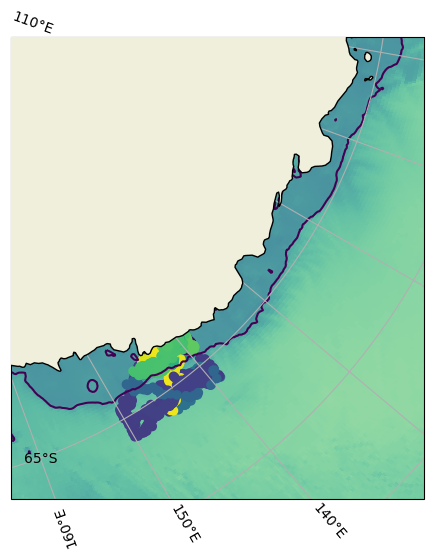

In [26]:
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
im=ax.scatter(meop.ds.lon,meop.ds.lat,c=meop.ds.time,transform=ccrs.PlateCarree())
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())

In [27]:
meop.ds['month'] = meop.ds.time.dt.month

In [28]:
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons
seasons = get_seasons(meop.ds)
print(len(seasons['autumn'].time))
print(len(seasons['winter'].time))
print(len(seasons['spring'].time))
print(len(seasons['summer'].time))


3918
1429
1592
3398


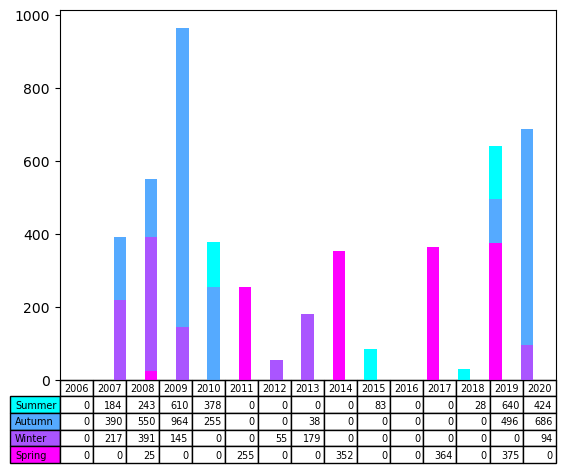

In [30]:
rows = ['Summer','Autumn','Winter','Spring']
cols = np.arange(2006,2021,1)
ally = xr.DataArray(cols, coords={'year':cols})
prep4table = lambda season: seasons[season].groupby('time.year').count().dsource.reindex_like(ally,fill_value=0).values
data = [prep4table('summer'),
        prep4table('autumn'),
        prep4table('winter'),
        prep4table('spring')]

# values = np.arange(0, 2500, 500)
# value_increment = 1000
# Get some pastel shades for the colors
colors = plt.cm.cool(np.linspace(0, 1, len(rows)))
n_rows = len(data)
index = np.arange(len(cols)) + 0.3
bar_width = 0.4
# Initialize the vertical-offset for the stacked bar chart.
y_offset = np.zeros(len(cols))
# Plot bars and create text labels for the table
for row in range(n_rows):
    plt.bar(index, data[row], bar_width, bottom=y_offset, color=colors[row])

plt.xticks([])
# Add a table at the bottom of the axes
the_table = plt.table(cellText=data,
                      rowLabels=rows,
                      rowColours=colors,
                      colLabels=cols,
                      loc='bottom')

In [31]:
sla_idx_data = sanom(mertz.crop_da(sla)).mean(['latitude','longitude'])
sla_idx_data = utls.detrend_dim(sla_idx_data,'time')

In [32]:
sic_idx_data = sanom(mertz.crop_da(sice_)).mean(['latitude','longitude'])
sic_idx_data = utls.detrend_dim(sic_idx_data,'time')

In [33]:
sam_idx_data = sanom(sam)
sam_idx_data = utls.detrend_dim(sam_idx_data,'time')

preparing data


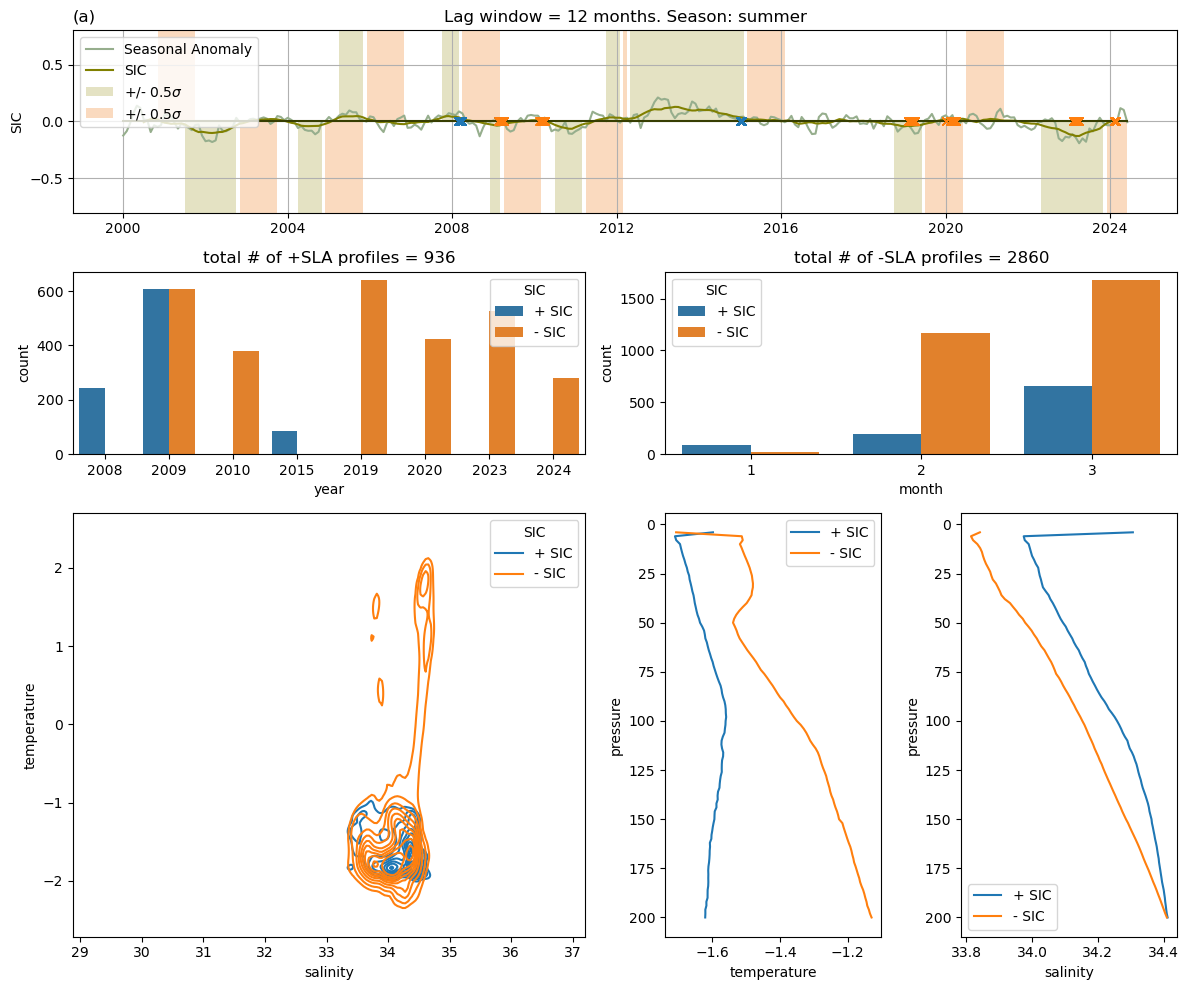

In [34]:
season='summer'
background_data = sic_idx_data
idx_data = background_data.rolling(time=12,center=True).mean('time')
title='SIC'
ylim=[-0.8,0.8]
lagwindow=12
cmp = Composite(idx_data,title,lagwindow=lagwindow)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(lagwindow,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_profiles, x='year', hue=cmp.idx_name,ax=ax2, hue_order=['+ {}'.format(title), '- {}'.format(title)])
sns.countplot(cmp.sns_profiles, x='month', hue=cmp.idx_name,ax=ax3, hue_order=['+ {}'.format(title), '- {}'.format(title)])
ax2.set_title('total # of +SLA profiles = {}'.format(len(cmp.t_pos)))
ax3.set_title('total # of -SLA profiles = {}'.format(len(cmp.t_neg)))

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name, hue_order=['+ {}'.format(title), '- {}'.format(title)])

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()

preparing data


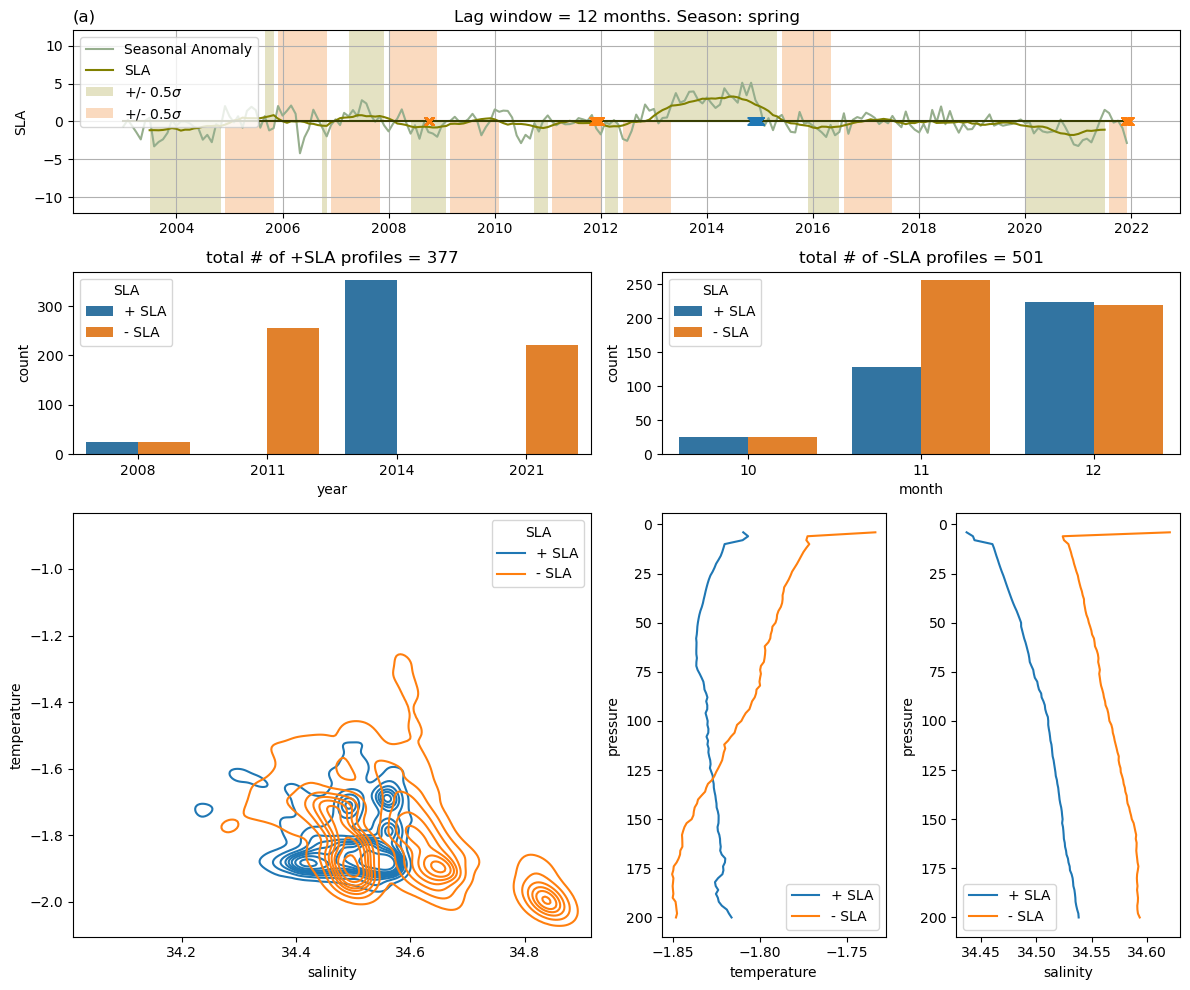

In [35]:
season='spring'
background_data = sla_idx_data
idx_data = background_data.rolling(time=12,center=True).mean('time')
title='SLA'
ylim=[-12,12]
lagwindow = 12

cmp = Composite(idx_data,title,lagwindow=lagwindow)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(lagwindow,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_profiles, x='year', hue=cmp.idx_name,ax=ax2,hue_order=['+ {}'.format(title), '- {}'.format(title)])
sns.countplot(cmp.sns_profiles, x='month', hue=cmp.idx_name,ax=ax3, hue_order=['+ {}'.format(title), '- {}'.format(title)])
ax2.set_title('total # of +SLA profiles = {}'.format(len(cmp.t_pos)))
ax3.set_title('total # of -SLA profiles = {}'.format(len(cmp.t_neg)))

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name, hue_order=['+ {}'.format(title), '- {}'.format(title)])

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()

preparing data


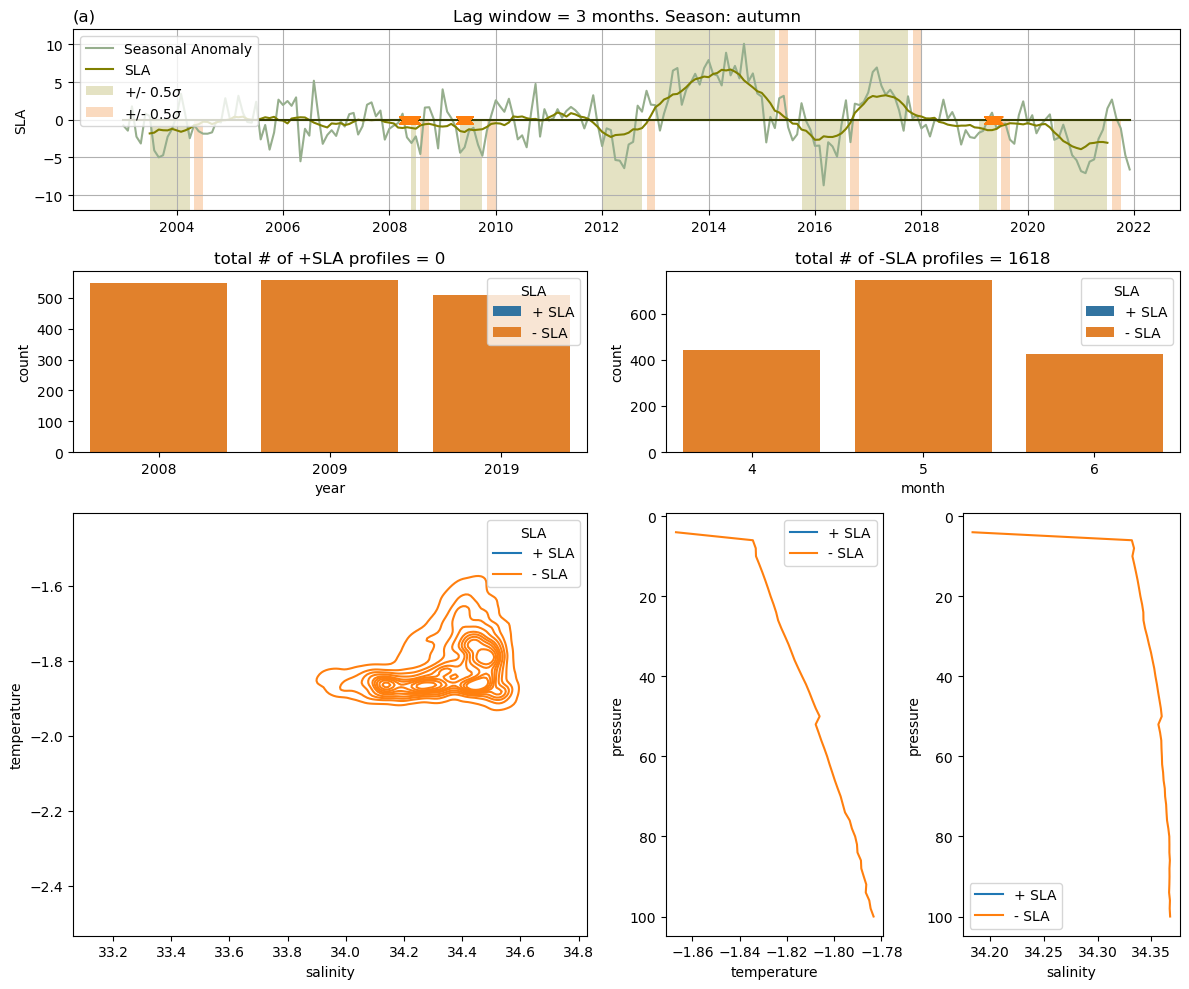

In [32]:
season='autumn'
background_data = sla_idx_data
idx_data = background_data.rolling(time=12,center=True).mean('time')
title='SLA'
ylim=[-12,12]
lagwindow = 3

cmp = Composite(idx_data,title,lagwindow=lagwindow)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(lagwindow,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_profiles, x='year', hue=cmp.idx_name,ax=ax2, hue_order=['+ {}'.format(title), '- {}'.format(title)])
sns.countplot(cmp.sns_profiles, x='month', hue=cmp.idx_name,ax=ax3, hue_order=['+ {}'.format(title), '- {}'.format(title)])
ax2.set_title('total # of +SLA profiles = {}'.format(len(cmp.t_pos)))
ax3.set_title('total # of -SLA profiles = {}'.format(len(cmp.t_neg)))

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name, hue_order=['+ {}'.format(title), '- {}'.format(title)])

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()

preparing data


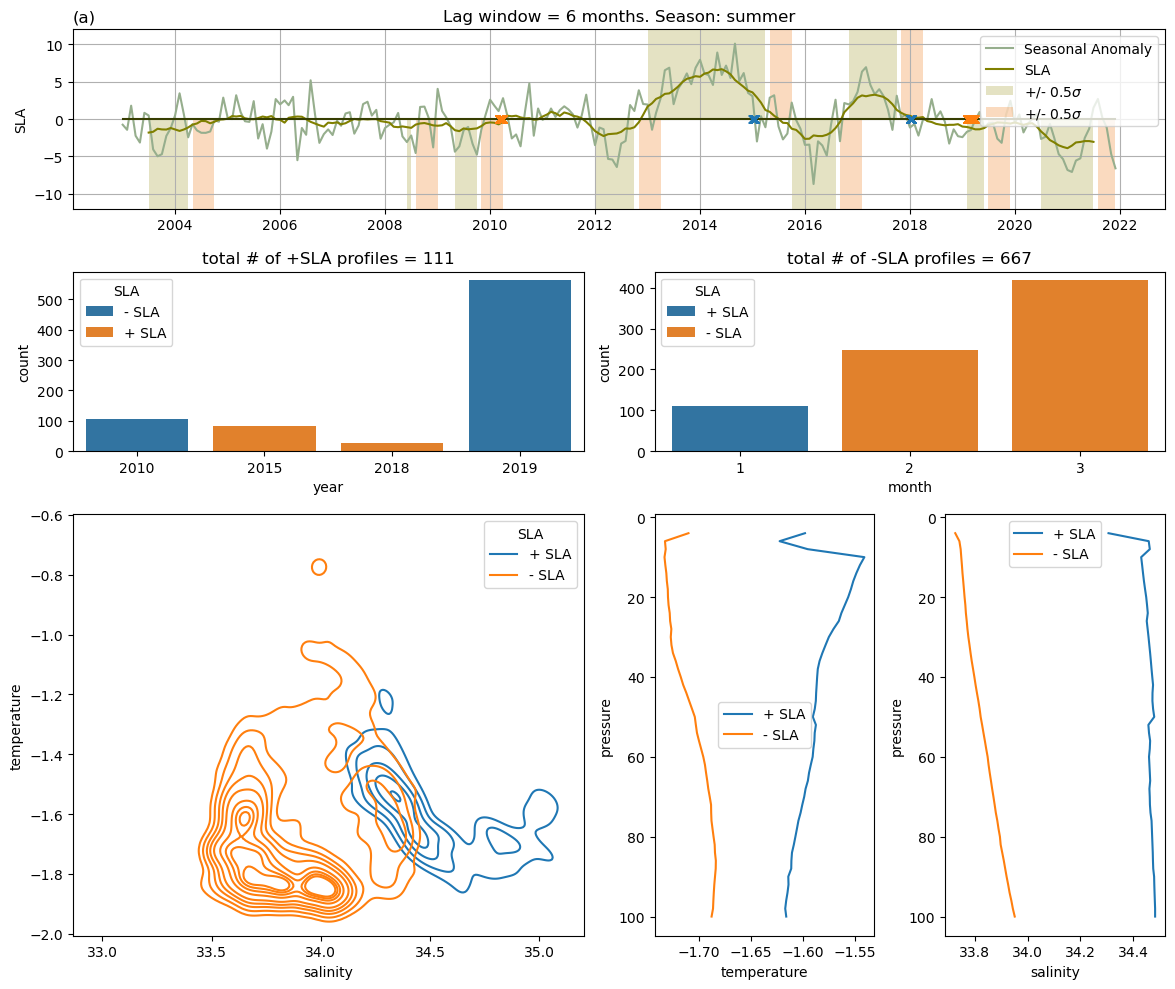

In [30]:
season='summer'
background_data = sla_idx_data
idx_data = background_data.rolling(time=12,center=True).mean('time')
title='SLA'
ylim=[-12,12]
lagwindow = 6

cmp = Composite(idx_data,title,lagwindow=lagwindow)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(lagwindow,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_profiles, x='year', hue=cmp.idx_name,ax=ax2)
sns.countplot(cmp.sns_profiles, x='month', hue=cmp.idx_name,ax=ax3)
ax2.set_title('total # of +SLA profiles = {}'.format(len(cmp.t_pos)))
ax3.set_title('total # of -SLA profiles = {}'.format(len(cmp.t_neg)))

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name)

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()